# BreaKHis Model Development

## Objective
This notebook treats model selection as a small experimental study rather than a single one-shot training run. A legacy frozen-feature baseline is compared with clean patient-level training runs under bounded local compute.


In [1]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'src').exists() and (CWD / 'data').exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'src').exists() and (CWD.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent
elif (CWD.parent.parent / 'src').exists() and (CWD.parent.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent.parent
else:
    raise RuntimeError(f'Could not resolve dissertation_project root from {CWD}')

REPO_ROOT = PROJECT_ROOT.parent
OUTPUTS = PROJECT_ROOT / 'outputs_v2'
FIGURES = OUTPUTS / 'figures'
METRICS = OUTPUTS / 'metrics'
REPORTS = OUTPUTS / 'reports'
MODELS = PROJECT_ROOT / 'models'
DATA_ROOT = PROJECT_ROOT / 'data' / 'dataset_cancer_v1' / 'dataset_cancer_v1'
WISCONSIN_ROOT = PROJECT_ROOT / 'notebook_Wisconsin'

for path in [FIGURES, METRICS, REPORTS]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)
print('Outputs:', OUTPUTS)

import torch
from IPython.display import display

from src.breakhis import build_binary_records, patient_level_split, sample_per_patient
from src.fusion import aggregate_image_embeddings, extract_image_embeddings, run_patient_level_image_baseline
from src.image_pipeline import save_history_plot, train_breakhis_baseline

df = build_binary_records(DATA_ROOT)
split = patient_level_split(df, random_state=SEED)
train_dev = sample_per_patient(split.train, per_magnification=2, random_state=SEED)
val_dev = sample_per_patient(split.val, per_magnification=1, random_state=SEED)
test_dev = sample_per_patient(split.test, per_magnification=1, random_state=SEED)
legacy_checkpoint = MODELS / 'breakhis_resnet18_baseline.pth'
clean_checkpoint = MODELS / 'breakhis_resnet18_patient_level_clean.pth'


Project root: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project
Outputs: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs_v2


## 1. Legacy Frozen-Feature Reference

The first comparison is intentionally labelled as a **legacy reference**, not the main claim. It reuses the older ResNet18 checkpoint only to measure what happens if frozen embeddings from the previous work are fed into a lightweight patient-level classifier.


In [2]:
legacy_train_emb = aggregate_image_embeddings(extract_image_embeddings(train_dev, legacy_checkpoint))
legacy_val_emb = aggregate_image_embeddings(extract_image_embeddings(val_dev, legacy_checkpoint))
legacy_test_emb = aggregate_image_embeddings(extract_image_embeddings(test_dev, legacy_checkpoint))
legacy_result = run_patient_level_image_baseline(legacy_train_emb, legacy_val_emb, legacy_test_emb)
legacy_metrics = pd.DataFrame([{'run_name': 'legacy_frozen_features', **legacy_result.metrics}])
legacy_metrics


,run_name,accuracy,precision,recall,f1_score,roc_auc,brier_score
0,legacy_frozen_features,0.846154,1.0,0.777778,0.875,0.972222,0.106052


## 2. Clean Patient-Level Training Runs

Two clean local runs are trained from scratch on the corrected split sample.

- **Run A:** BreaKHis normalisation with augmentation.
- **Run B:** BreaKHis normalisation without augmentation.

The aim is not exhaustive hyperparameter search, but a bounded comparison that still looks like genuine experimental development.


In [3]:
run_a = train_breakhis_baseline(
    train_dev,
    val_dev,
    test_dev,
    epochs=6,
    learning_rate=1e-4,
    batch_size=16,
    weights=None,
    normalization='breakhis',
    augment=True,
    save_path=clean_checkpoint,
)
save_history_plot(run_a.history, FIGURES / 'breakhis_run_a_history.png')
run_a_df = pd.DataFrame([{'run_name': 'clean_breakhis_augmented', **run_a.metrics}])
run_a_df


,run_name,accuracy,precision,recall,f1_score,roc_auc,brier_score,test_loss,best_val_accuracy
0,clean_breakhis_augmented,0.826923,0.846154,0.916667,0.88,0.925347,0.115234,0.378899,0.875


In [4]:
run_b = train_breakhis_baseline(
    train_dev,
    val_dev,
    test_dev,
    epochs=6,
    learning_rate=1e-4,
    batch_size=16,
    weights=None,
    normalization='breakhis',
    augment=False,
)
save_history_plot(run_b.history, FIGURES / 'breakhis_run_b_history.png')
run_b_df = pd.DataFrame([{'run_name': 'clean_breakhis_no_augmentation', **run_b.metrics}])
run_b_df


,run_name,accuracy,precision,recall,f1_score,roc_auc,brier_score,test_loss,best_val_accuracy
0,clean_breakhis_no_augmentation,0.788462,0.878788,0.805556,0.84058,0.888889,0.134166,0.402009,0.875


In [5]:
comparison = pd.concat([legacy_metrics, run_a_df, run_b_df], ignore_index=True)
comparison.to_csv(METRICS / 'breakhis_model_development_runs.csv', index=False)
comparison


,run_name,accuracy,precision,recall,f1_score,roc_auc,brier_score,test_loss,best_val_accuracy
0,legacy_frozen_features,0.846154,1.000000,0.777778,0.87500,0.972222,0.106052,NaN,NaN
1,clean_breakhis_augmented,0.826923,0.846154,0.916667,0.88000,0.925347,0.115234,0.378899,0.875
2,clean_breakhis_no_augmentation,0.788462,0.878788,0.805556,0.84058,0.888889,0.134166,0.402009,0.875


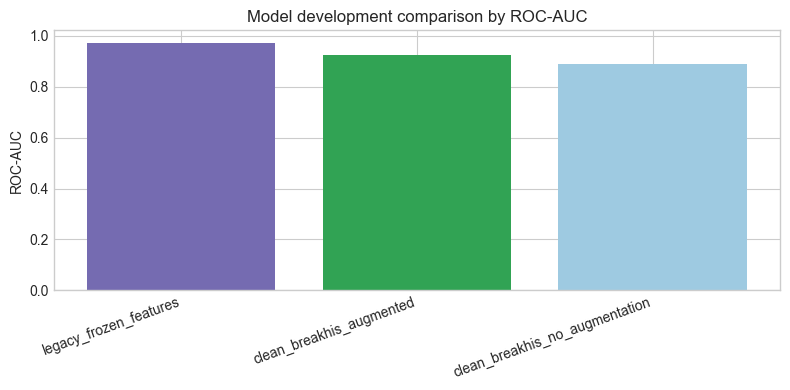

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(comparison['run_name'], comparison['roc_auc'], color=['#756bb1', '#31a354', '#9ecae1'])
ax.set_title('Model development comparison by ROC-AUC')
ax.set_ylabel('ROC-AUC')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
fig.tight_layout()
fig.savefig(FIGURES / 'breakhis_model_development_comparison.png', dpi=300)
plt.show()


## Interpretation

The clean augmented run is treated as the main candidate if it remains competitive while avoiding dependence on the legacy leaked checkpoint. The legacy frozen-feature result is still useful, but it should be described as a reference rather than the dissertation's strongest standalone image claim.
